# Introduction of Numpy Broadcasting
> https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html  Korean Translation, Arrangement
- toc: True


> https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html  Korean Translation, Arrangement

In [1]:
#hide
import numpy as np

In [2]:
a = np.array([0,1,2])
b = np.array([5,5,5])
a + b

array([5, 6, 7])

Broadcasting은  다른 사이즈를 가진 배열을 아래와 같은 이항연산(binart operation)을 가능하게 만든다. 예를들어 스칼라(1차원배열)를 배열에 쉽게 더할 수 있다.

In [4]:
a + 5

array([5, 6, 7])

이러한 연산을 `5`를 `[5,5,5]`로 늘리거나 복사하고 더한다고 생각할 수 있다. Numpy Broadcasting의 장점은 그런 복사가 실제로 일어나지 않아 메모리를 절약한다. 하지만 복사한다고 생각하는 것이 Broadcasting을 이해하기에 편하다.

또한 배열을 더 높은 차원의 배열로 확장할 수 있다. 1차원의 배열을 2차원의 배열에 더한 결과를 보자


In [6]:
M = np.ones((3,3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [7]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

1차원 배열 `a`가 `M`의 2번째차원에 맞추기 위해 broadcasting되었다.

위와 같이 간단한 예는 이해하기 쉽지만 더 복잡한 경우에는 두개의 배열에서 동시에 broadcasting이 일어난다. 아래의 예를 살펴보자

In [8]:
a = np.arange(3)
b = np.arange(3)[:, np.newaxis]

print(a)
print(b)

[0 1 2]
[[0]
 [1]
 [2]]


In [9]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

하나의 값을 다른 배열에 맞추기 위해 broadcasting했을 때와 마찬가지로 위의 예에서는 `a`, `b` 두 배열 전부 공통 크기를 맞추기 위해 broadcasting 되었고  2차원 배열이 되었다.

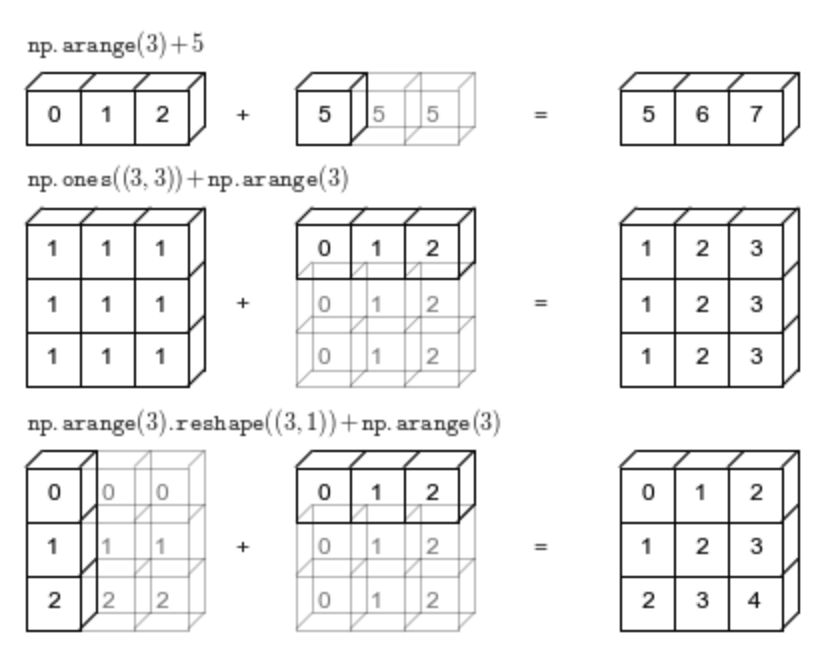

# Rules of Broadcasting

Numpy Broadcasting은 두 배열사이의 상호작용을 결정하기 위해 엄격한 규칙을 따른다.

- Rule1: 만약 두 배열의 차원의 개수가 다르면 작은 차원을 가진 배열의 왼쪽으로 패딩된다
- Rule2: 만약 두배열이 어떠한 한 차수의 개수가 일치하지 않고, 그 배열의 차원의 shape 1을 가진다면 그 차원은 다른 배열의 shape에 맞춰 늘어난다.
- Rule3: 만약 어떠한 차원의 크기가 일치하지않고 1의 shape을 가진 배열이 없다면 error가 발생하게 된다.

## Broadcasting example 1

하나의 배열에서만 broadcasting이 필요한 경우

In [10]:
M = np.ones((2,3))
a = np.arange(3)

위의 두 배열에 대한 연산을 살펴보자. 
두 배열의 shape은 아래와 같다.

- `M.shape = (2,3)`
- `a.shape = (3,)`

Rule1에 의해 더 적은 차원을 가지는 a배열은 왼쪽으로 1로 패딩되는 것을 알수 있다.

- `M.shape -> (2,3)`
- `a.shape -> (1,3)`

Rule2에 의해 첫 번째 차원의 크기가 일치하지 않아 1의 크기를 가진 차원이 더 큰 크기를 가진 차원에 맞춰지는 것을 알 수 있다.

- `M.shape ->(2,3)`
- `a.shape ->(2,3)`

이제 차원의 크기들이 일차하는 것을 알 수 있다. 최종 shape은 `(2,3)`이 된다

In [11]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

## Broadcasting example 2

두 배열 모두 broadcasting이 필요한 경우

In [12]:
a = np.arange(3).reshape((3,1))
b = np.arange(3)

위 배열들의 shape은 아래와 같다.

- `a.shape = (3,1)`
- `b.shape = (3,)`

Rule1에 의해 b는 첫번째 차원에 크기1을 가지도록 패딩된다.

- `a.shape -> (3,1)`
- `b.shape -> (1,3)`

그리고 Rule2에 의해 두 열 모두 다른 배열의 같은차원의 크기와 일치하도록 broadcasting된다.

- `a.shape -> (3,3)`
- `b.shape -> (3,3)`


In [13]:
a + b 

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

## Broadcasting example 3

두 배열이 broadcasting 될 수 없는 예

In [15]:
M = np.ones((3,2))
a = np.arange(3)

첫 예제와 달리 M에 전치되었다. 이러한 상황이 계산에 어떠한 영향을 미칠까? 배열의 shape은 아래와 같다.

- `M.shape = (3,2)`
- `a.shape = (3,)`

Rule1에 의해 a의 왼쪽으로 크기1을 가진 차원이 추가된다. 

- `M.shape -> (3,2)`
- `a.shape -> (1,3)`

Rule2에 의해 a의 첫번째 차원의 크기가 M과 같도록 늘어난다.

- `M.shape -> (3,2)`
- `a.shape -> (3,3)`

두 배열의 두 번째 차원의 크기각 둘 중 하나라도 1이 아닌 상태에서 차원의 크기가 일치하지 않아 Rule3에 의해 error가 발생한다.

In [16]:
M + a

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

배열 a를 오른쪽으로 padding하면 위와 같은 에러가 발생하지 않지만 규칙으로는 불명확함을 없애기 위해 왼쪽으로 패딩하도록 되어있다. 만약 오른쪽을 패딩하고 싶다면 아래와 같이 np.newaxis를 사용하면 된다 

In [17]:
a[:, np.newaxis].shape

(3, 1)

In [18]:
M + a[:, np.newaxis]

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

Numpy Broadcasting은 어떠한 넘파이 이항연산 함수에서도 사용가능하다. 예를 들어 `logaddexp(a,b) - log(exp(a) + exp(b))`와 같은 함수도 사용가능하다 

In [19]:
np.logaddexp(M, a[:, np.newaxis])


array([[1.31326169, 1.31326169],
       [1.69314718, 1.69314718],
       [2.31326169, 2.31326169]])

# Broadcasting in Practice

## Centering an array

Numpy의 ufunc들은 Numpy유저들이 느린 파이썬 반복문을 사용하지 않고 다양한 연산을 수행할 수 있도록 만들어 줬다. 대표적으로 Centering할때 편리학게 할 수있다.

In [21]:
X = np.random.random((10, 3))

In [22]:
# 첫번째 차원 방향으로 mean함수 실행

Xmean = X.mean(0)
Xmean

array([0.53485911, 0.69955288, 0.59469372])

In [23]:
# Xmean을 X에 빼줘서 centring
X_centered = X - Xmean

In [24]:
# cetering 되었기 때문에 X_centered를 첫번째 차원뱡향의 평균을 구했을 때 0에 근접해야함

X_centered.mean(0)

array([-4.44089210e-17, -3.33066907e-17, -7.77156117e-17])

## Plotting a two-dimensional function

Broadcasting은 이차원 함수로부터 나온 결과 이미지를 보여주는 데에 유용하게 사용된다. 

In [25]:
# x and y have 50 steps form 0 to 5
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y*x) * np.cos(x)

In [33]:
#hide
%matplotlib inline
import matplotlib.pyplot as plt


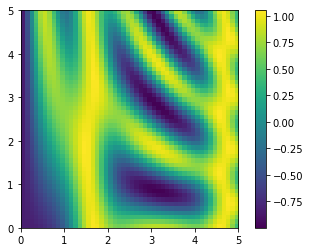

In [34]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5],
          cmap='viridis')
plt.colorbar();